# Uploading Datasets

In [1]:
#installing kaggle
! pip install kaggle --quiet

In [ ]:
#uploading kaggle file
from google.colab import files
files.upload()

In [ ]:
#kaggle directory
!mkdir ~/.kaggle

In [4]:
#copy kaggle file
!cp kaggle.json ~/.kaggle/

In [ ]:
ls -ltr ~/.kaggle

In [6]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions list

In [ ]:
!kaggle datasets list

In [ ]:
!kaggle datasets download -d 'burak3ergun/loan-data-set/'

In [ ]:
!unzip loan-data-set.zip

In [11]:
!rm loan-data-set.zip

In [ ]:
!rm -r sample_data

In [ ]:
!ls

# EDA




In [14]:
#importing libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("loan_data_set.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [16]:
df.isnull().sum()

#whether is it okay to have loan amout , loan amt term as null, if not remove the rows.

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


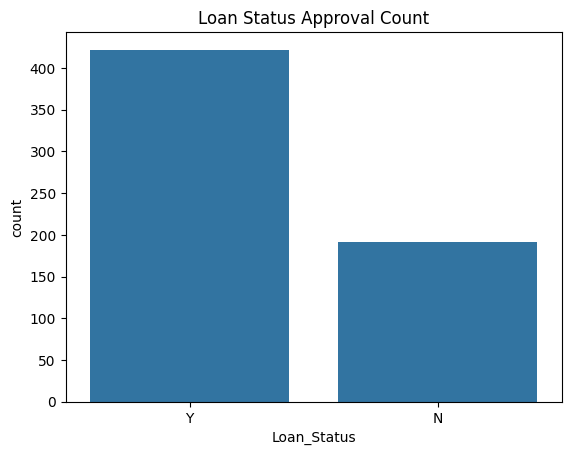

,proportion
Loan_Status,
Y,0.687296
N,0.312704


In [17]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Approval Count")
plt.show()
df['Loan_Status'].value_counts(normalize=True)

# The dataset is imbalanced:
# ~69% approved (Y)
# ~31% rejected (N)
# This may bias the model toward predicting approvals
# Evaluation metrics beyond accuracy is required

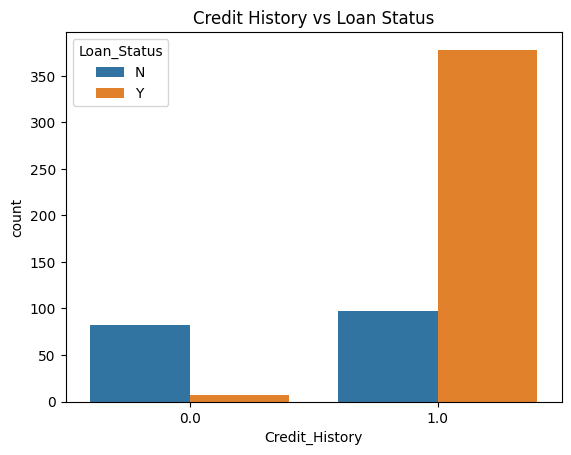

In [18]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

# Applicants with a credit history (1.0) are significantly more likely to have their loans approved.
# Suggests that Credit_History is a strong predictor of loan approval.

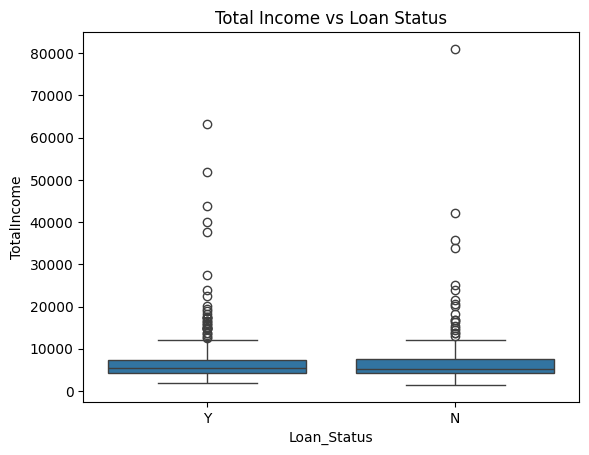

In [19]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
sns.boxplot(x='Loan_Status', y='TotalIncome', data=df)
plt.title("Total Income vs Loan Status")
plt.show()

# Distribution of TotalIncome is very similar for both approved (Y) and rejected (N) applicants
# Median income values for both groups are nearly the same
# Large overlap between approved and rejected applicants
# High-income outliers exist in both groups

# Conclusion: TotalIncome is not a strong predictor of loan approval
#             Higher income does not guarantee loan approval

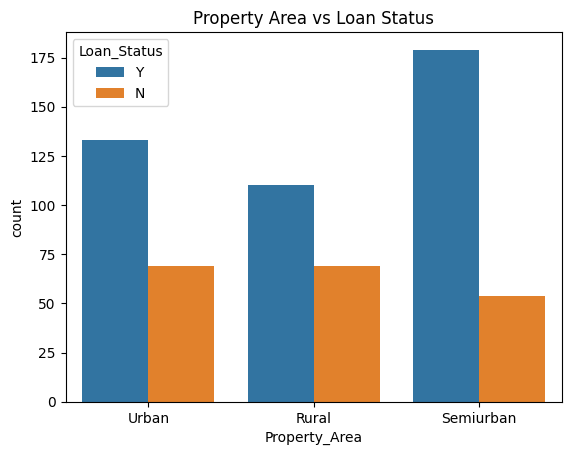

In [20]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Status")
plt.show()

# Loan approvals vary across different property areas
# Semiurban areas have the highest number of approved loans
# Rural areas show a less unbalanced distribution between approvals and rejections compared to others

#Conclusion: Higher likelihood of approval in semiurban regions

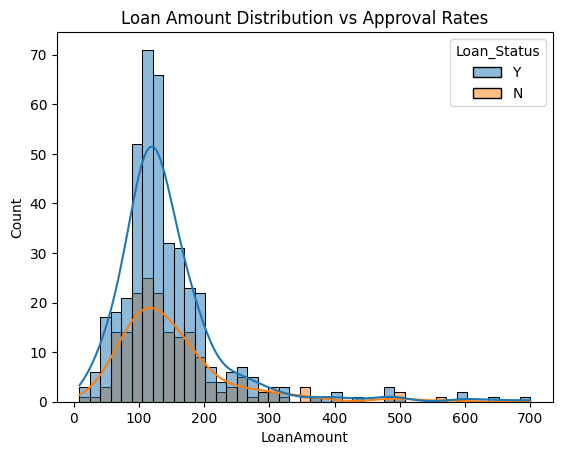

Loan_Status,N,Y
LoanAmount_Bin,,
"(8.309, 147.2]",0.282723,0.717277
"(147.2, 285.4]",0.335227,0.664773
"(285.4, 423.6]",0.476190,0.523810
"(423.6, 561.8]",0.375000,0.625000
"(561.8, 700.0]",0.200000,0.800000


In [21]:
sns.histplot(data=df, x='LoanAmount', hue='Loan_Status', kde=True)
plt.title("Loan Amount Distribution vs Approval Rates")
plt.show()

# Loan amount distribution is right-skewed
# Majority of loans fall within the range of approximately 100–200

df['LoanAmount_Bin'] = pd.cut(df['LoanAmount'], bins=5)
pd.crosstab(df['LoanAmount_Bin'], df['Loan_Status'], normalize='index')

# 1. Low loan amounts (8–147)
# Approximately 71% approved and 28% rejected
# Small loans are more likely to be approved

# 2. Medium loan amounts (147–285)
# Approximately 66% approved and 33% rejected
# Approval rate decreases slightly as loan amount increases

# 3. Higher loan amounts (285–423)
# Approximately 52% approved and 47% rejected
# Approval and rejection rates are nearly equal, indicating higher risk

# 4. Very high loan amounts (423–561)
# Approximately 62% approved and 37% rejected
# Slight increase in approvals, possibly due to fewer data points

# 5. Extreme loan amounts (561–700)
# Approximately 80% approved and 20% rejected
# Results are unreliable due to very small sample size

# Main trend
# As loan amount increases, approval rates generally decrease
# Lower loan amounts have higher approval rates
# Mid to higher loan amounts show more balanced or increased rejections

# Overall conclusion
# Loan amount has a moderate impact on approval but is not a strong predictor

In [22]:
df['Education'].value_counts(normalize=True)

# Education distribution shows that approximately 78% of applicants are graduates,
# while only about 22% are non-graduates

,proportion
Education,
Graduate,0.781759
Not Graduate,0.218241


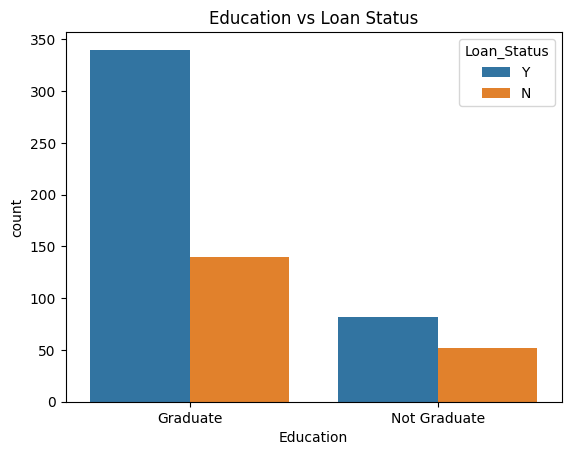

Loan_Status,N,Y
Education,,
Graduate,0.291667,0.708333
Not Graduate,0.388060,0.611940


In [23]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()
pd.crosstab(df['Education'], df['Loan_Status'], normalize='index')

# The higher number of approvals for graduates is partly due to their larger representation in the dataset
# When comparing approval rates (proportions), the difference between graduates and non-graduates is relatively small
# This suggests that education has some influence, but is not a strong predictor of loan approval

# Data Cleaning & Feature Engineering

In [24]:
# Drop unnecessary columns
df.drop('Loan_ID', axis=1, inplace=True, errors='ignore')
df.drop(['LoanAmount_Bin', 'Income_Bin'], axis=1, inplace=True, errors='ignore')

In [25]:
# Fix Dependents
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Dependents'] = df['Dependents'].astype(int)

In [26]:
# Fill numerical missing values
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Fill categorical missing values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [27]:
# Feature engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['LoanIncomeRatio'] = df['LoanAmount'] / df['TotalIncome']

In [28]:
# Drop original income columns
df.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1, inplace=True) #later try including it if necessary to improve the model performance

In [29]:
# Manual encoding for binary categorical columns
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Married'] = df['Married'].map({'No': 0, 'Yes': 1})
df['Education'] = df['Education'].map({'Not Graduate': 0, 'Graduate': 1})
df['Self_Employed'] = df['Self_Employed'].map({'No': 0, 'Yes': 1})

In [30]:
# Encode target
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Encode Property_Area only
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

In [31]:
# Convert boolean dummy columns to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# rename property area columns
df.rename(columns={
    'Property_Area_Semiurban': 'Semiurban',
    'Property_Area_Urban': 'Urban'
}, inplace=True)

In [32]:
# Reorder columns
ordered_cols = [
    'Dependents',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    'TotalIncome',
    'LoanIncomeRatio',
    'Gender',          # Female = 1, Male = 0
    'Married',         # Married = 1, Not married = 0
    'Education',       # Graduate = 1, Not graduate = 0
    'Self_Employed',   # Yes = 1, No = 0
    'Semiurban',
    'Urban',           # if both are 0, then Property_Area = Rural
    'Loan_Status'
]

df = df[ordered_cols]

In [33]:
df.head()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanIncomeRatio,Gender,Married,Education,Self_Employed,Semiurban,Urban,Loan_Status
0,0,128.0,360.0,1.0,5849.0,0.021884,0,0,1,0,0,1,1
1,1,128.0,360.0,1.0,6091.0,0.021015,0,1,1,0,0,0,0
2,0,66.0,360.0,1.0,3000.0,0.022000,0,1,1,1,0,1,1
3,0,120.0,360.0,1.0,4941.0,0.024287,0,1,0,0,0,1,1
4,0,141.0,360.0,1.0,6000.0,0.023500,0,0,1,0,0,1,1


In [34]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        614 non-null    int64  
 1   LoanAmount        614 non-null    float64
 2   Loan_Amount_Term  614 non-null    float64
 3   Credit_History    614 non-null    float64
 4   TotalIncome       614 non-null    float64
 5   LoanIncomeRatio   614 non-null    float64
 6   Gender            614 non-null    int64  
 7   Married           614 non-null    int64  
 8   Education         614 non-null    int64  
 9   Self_Employed     614 non-null    int64  
 10  Semiurban         614 non-null    int64  
 11  Urban             614 non-null    int64  
 12  Loan_Status       614 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 62.5 KB


,0
Dependents,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
TotalIncome,0
LoanIncomeRatio,0
Gender,0
Married,0
Education,0
Self_Employed,0


# Train/Validation/Test

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X = df.iloc[:, :-1]   # all columns except Loan_Status
y = df.iloc[:, -1]    # Loan_Status. (TARGET VARIABLE!!!)

In [37]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# data has been divided into:
# X_train, y_train → 80% (used to train the model)
# X_val, y_val     → 10% (used to tune/validate)
# X_test, y_test   → 10% (used for final evaluation)

In [39]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 491
Validation: 61
Test: 62


# Initial  Model Training and Validation



LEARNING STRATEGY
OVERFITTING, UNDERFITTING

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Model 1: Logistic Regression (baseline model)

In [42]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [43]:
y_val_pred = log_model.predict(X_val_scaled)

In [44]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.8360655737704918
Precision: 0.82
Recall: 0.9761904761904762
F1 Score: 0.8913043478260869

Confusion Matrix:
[[10  9]
 [ 1 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.53      0.67        19
           1       0.82      0.98      0.89        42

    accuracy                           0.84        61
   macro avg       0.86      0.75      0.78        61
weighted avg       0.85      0.84      0.82        61



In [45]:
# Accuracy: 84% (but not reliable due to imbalance)
# Very good at predicting approvals (41/42 correct)
# Weak at predicting rejections (10/19 correct)
# High recall for approvals (0.98) → almost all good applicants approved
# Low recall for rejections (0.53) → many bad applicants missed
# Model is biased toward approving loans
# Caused by imbalanced dataset (more approvals than rejections)

Model 2: Decision Tree

In [46]:
tree_model = DecisionTreeClassifier(
    max_depth=4,   # prevents overfitting
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [47]:
y_val_pred = tree_model.predict(X_val)

In [48]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.8032786885245902
Precision: 0.8125
Recall: 0.9285714285714286
F1 Score: 0.8666666666666667

Confusion Matrix:
[[10  9]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.53      0.62        19
           1       0.81      0.93      0.87        42

    accuracy                           0.80        61
   macro avg       0.79      0.73      0.75        61
weighted avg       0.80      0.80      0.79        61



In [49]:
# Accuracy dropped to 80% (worse than Logistic Regression)
# No improvement in rejection detection (10/19 correct)
# Worse at approvals (39/42 correct vs 41/42 before)
# Recall for approvals decreased (0.93)
# Recall for rejections unchanged (0.53)
# Model still biased toward approvals
# Does not solve imbalance problem

Model 3: Random Forest

In [50]:
rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=5,        # controls overfitting
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [51]:
y_val_pred = rf_model.predict(X_val)

In [52]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.8524590163934426
Precision: 0.8367346938775511
Recall: 0.9761904761904762
F1 Score: 0.9010989010989011

Confusion Matrix:
[[11  8]
 [ 1 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        19
           1       0.84      0.98      0.90        42

    accuracy                           0.85        61
   macro avg       0.88      0.78      0.81        61
weighted avg       0.86      0.85      0.84        61



In [53]:
# Best overall performance (85% accuracy, highest F1)
# Improved rejection detection (11/19 correct vs 10 before)
# Reduced false approvals (8 vs 9 before)
# Maintains strong approval prediction (41/42 correct)
# Recall for rejections slightly improved (0.58)
# Still somewhat biased toward approvals, but improved

Model 4: KNN

In [54]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [55]:
y_val_pred = knn_model.predict(X_val_scaled)

In [56]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.8360655737704918
Precision: 0.8333333333333334
Recall: 0.9523809523809523
F1 Score: 0.8888888888888888

Confusion Matrix:
[[11  8]
 [ 2 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        19
           1       0.83      0.95      0.89        42

    accuracy                           0.84        61
   macro avg       0.84      0.77      0.79        61
weighted avg       0.84      0.84      0.83        61



In [57]:
# Accuracy: 84% (similar to Logistic Regression)
# Improved rejection detection (11/19 correct)
# Slight drop in approval accuracy (40/42 correct)
# Recall for rejections improved (0.58)
# Recall for approvals slightly lower (0.95)
# More balanced than Logistic Regression

Model 5: SVM

In [58]:
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [59]:
y_val_pred = svm_model.predict(X_val_scaled)

In [60]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.8360655737704918
Precision: 0.82
Recall: 0.9761904761904762
F1 Score: 0.8913043478260869

Confusion Matrix:
[[10  9]
 [ 1 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.53      0.67        19
           1       0.82      0.98      0.89        42

    accuracy                           0.84        61
   macro avg       0.86      0.75      0.78        61
weighted avg       0.85      0.84      0.82        61



In [61]:
# Accuracy: 84%
# Very strong at predicting approvals (41/42 correct)
# Weak at predicting rejections (10/19 correct)
# High recall for approvals (0.98) → almost all good applicants approved
# Low recall for rejections (0.53) → many bad applicants missed
# Similar behavior to Logistic Regression
# Model is biased toward approvals

Model 6: Naive Bayes

In [62]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [63]:
y_val_pred = nb_model.predict(X_val)

In [64]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.8032786885245902
Precision: 0.8125
Recall: 0.9285714285714286
F1 Score: 0.8666666666666667

Confusion Matrix:
[[10  9]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.53      0.62        19
           1       0.81      0.93      0.87        42

    accuracy                           0.80        61
   macro avg       0.79      0.73      0.75        61
weighted avg       0.80      0.80      0.79        61



In [65]:
# Accuracy: 80% (lower than most models)
# Strong at predicting approvals (39/42 correct)
# Weak at predicting rejections (10/19 correct)
# Recall for approvals: 0.93 (good but lower than Logistic/SVM)
# Recall for rejections: 0.53 (no improvement)
# Similar behavior to Decision Tree
# Still biased toward approvals